In [1]:
!pip install tonic


[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [4]:
import numpy as np

def splat_conv_eq5(
    events,            # (N,4) array: [x, y, t, p] where p in {+1, -1}
    H, W,              # sensor height/width
    t0, t1,            # time window start/end (same units as t in events)
    dt,                # time bin size
    K_pos, K_neg=None  # kernel tables: (5,5,5); if K_neg None, reuse K_pos
):
    """
    Implements event-centered kernel convolution (Eq. 5) into a time-binned grid.

    Output: Y_pos, Y_neg each shape (H, W, B) where B = floor((t1-t0)/dt).
    """
    if K_neg is None:
        K_neg = K_pos

    # 1) bins
    B = int(np.floor((t1 - t0) / dt))
    Y_pos = np.zeros((H, W, B), dtype=np.float32)
    Y_neg = np.zeros((H, W, B), dtype=np.float32)

    # Kernel support for 5x5x5 => offsets -2..2
    OFFS = [-2, -1, 0, 1, 2]
    CENTER = 2  # because offset 0 maps to index 2

    for (xk, yk, tk, pk) in events:
        # 2) time bin
        # TODO(you): compute bk = floor((tk - t0) / dt) as an int
        bk = int(np.floor((tk - t0) / dt))

        # 3) skip if out of time range (same-size grid => implicit zero outside)
        # TODO(you): write the bounds check for bk
        if bk > B or bk < 0:
            continue

        # 4) choose polarity channel & kernel table
        # TODO(you): pick Y and K depending on pk (+1 -> pos, -1 -> neg)
        Y = Y_pos if pk == 1 else Y_neg
        K = K_pos if pk == 1 else K_neg

        # 5) per-event value f_k (per paper: can be 1 for count-conv)
        # TODO(you): set fk (start with 1.0)
        fk = 1.0

        # 6) splat kernel support into output
        for dy in OFFS:
            yy = int(yk + dy)
            if yy < 0 or yy >= H:
                continue

            ky = dy + CENTER  # offset -> kernel index

            for dx in OFFS:
                xx = int(xk + dx)
                if xx < 0 or xx >= W:
                    continue

                kx = dx + CENTER

                for db in OFFS: # time-bin offset
                    bb = int(bk + db)
                    if bb < 0 or bb >= B:
                        continue

                    kb = db + CENTER

                    # TODO(you): apply Eq. (5) update:
                    Y[yy, xx, bb] += fk * K[ky, kx, kb]
                    pass


    return Y_pos, Y_neg


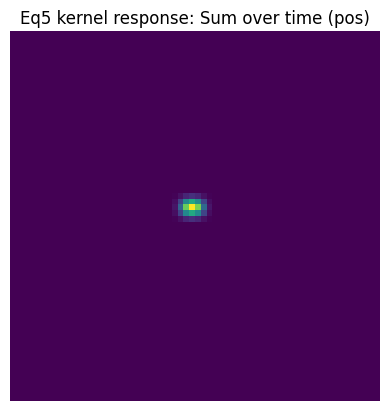

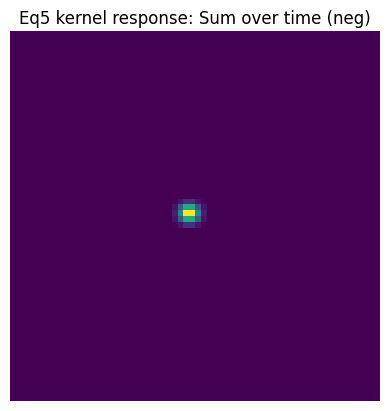

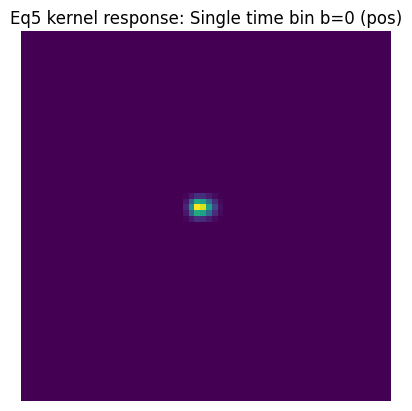

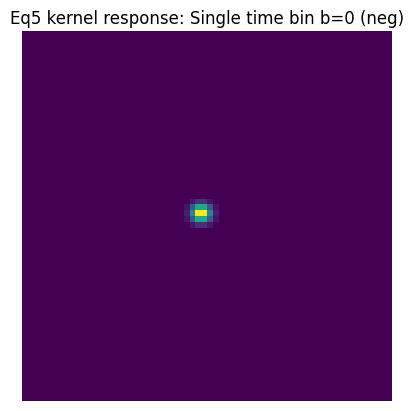

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_Y(Y_pos, Y_neg, b=None, title_prefix=""):
    """
    Y_pos, Y_neg: (H, W, B)
    b: optional time-bin index to visualize a single slice
    """
    H, W, B = Y_pos.shape
    assert Y_neg.shape == (H, W, B)

    # 1) Sum-over-time projections (good first sanity check)
    I_pos = Y_pos.sum(axis=2)
    I_neg = Y_neg.sum(axis=2)

    plt.figure()
    plt.title(f"{title_prefix}Sum over time (pos)")
    plt.imshow(I_pos)
    plt.axis("off")

    plt.figure()
    plt.title(f"{title_prefix}Sum over time (neg)")
    plt.imshow(I_neg)
    plt.axis("off")

    # 2) Optional: visualize a single time slice
    if b is None:
        b = B // 2  # pick a middle bin by default
    b = int(np.clip(b, 0, B - 1))

    plt.figure()
    plt.title(f"{title_prefix}Single time bin b={b} (pos)")
    plt.imshow(Y_pos[:, :, b])
    plt.axis("off")

    plt.figure()
    plt.title(f"{title_prefix}Single time bin b={b} (neg)")
    plt.imshow(Y_neg[:, :, b])
    plt.axis("off")

    plt.show()


# Fake event stream: (x, y, t, p)
events = np.array([
    [30, 30, 0.010, +1],
    [31, 30, 0.011, +1],
    [32, 30, 0.012, +1],
    [30, 31, 0.013, -1],
    [31, 31, 0.014, -1],
], dtype=np.float32)

H, W = 64, 64
t0 = 0.0
t1 = 0.05          # 50 ms window
dt = 0.005         # 5 ms bins → B = 10

def make_kernel(size=5, sigma_xy=1.0, tau=1.0):
    CENTER = size // 2
    K = np.zeros((size, size, size), dtype=np.float32)

    for ky in range(size):
        for kx in range(size):
            for kb in range(size):
                dx = kx - CENTER
                dy = ky - CENTER
                db = kb - CENTER

                spatial = np.exp(-(dx*dx + dy*dy) / (2 * sigma_xy**2))
                temporal = np.exp(-abs(db) / tau)

                K[ky, kx, kb] = spatial * temporal

    return K

K = make_kernel()

Y_pos, Y_neg = splat_conv_eq5(
    events=events,
    H=H,
    W=W,
    t0=t0,
    t1=t1,
    dt=dt,
    K_pos=K
)
visualize_Y(Y_pos, Y_neg, b=0, title_prefix="Eq5 kernel response: ")


In [ ]:
import torch
import torch.nn as nn

class KernelMLP(nn.Module):
    def __init__(self, hidden=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden),
            # TODO: activation
            nn.Linear(hidden, hidden),
            # TODO: activation
            nn.Linear(hidden, 1),
        )

    def forward(self, dxyz_t):  # shape (..., 3)
        return self.net(dxyz_t) # shape (..., 1)


In [5]:
import numpy as np
import torch
import torch.nn as nn

# -------------------------
# 1) Learned kernel: MLP(3 -> 30 -> 30 -> 1)
# -------------------------
class KernelMLP(nn.Module):
    def __init__(self, hidden=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):          # x: (..., 3)
        return self.net(x)         # (..., 1)


# -------------------------
# 2) End-to-end learned grid representation (continuous time grid)
#    Event-centered "splat": for each event, add its learned activation map into Y
# -------------------------
@torch.no_grad()
def _ensure_long(x):
    return x.long()

def learned_representation_eq6(
    events,          # torch.Tensor (N,4): [x, y, t, p] with p in {+1,-1}
    H, W,            # sensor H,W
    t_grid,          # torch.Tensor (L,) continuous query times
    kernel_mlp,      # KernelMLP
    t_support=0.05,  # seconds, use |t_l - t_k| <= t_support
    spatial_radius=2,# 5x5 => radius 2
    device=None,
):
    """
    Returns:
      Y_pos, Y_neg: (H, W, L) grid-like representations.
    Notes:
      - Measurement f is fixed here as fk = 1.0 (per excerpt "do not learn measurement").
      - Fully differentiable w.r.t. kernel_mlp parameters (Y does not require grad).
    """
    if device is None:
        device = next(kernel_mlp.parameters()).device

    # Move inputs
    if not isinstance(events, torch.Tensor):
        events = torch.tensor(events, dtype=torch.float32)
    events = events.to(device)

    if not isinstance(t_grid, torch.Tensor):
        t_grid = torch.tensor(t_grid, dtype=torch.float32)
    t_grid = t_grid.to(device)

    N = events.shape[0]
    L = t_grid.shape[0]

    # Output grids (no grad needed on outputs themselves)
    Y_pos = torch.zeros((H, W, L), dtype=torch.float32)
    Y_neg = torch.zeros((H, W, L), dtype=torch.float32)

    OFFS = list(range(-spatial_radius, spatial_radius + 1))  # e.g., [-2,-1,0,1,2]

    # Enable grad through the MLP (do NOT wrap the whole function in no_grad)
    # So we’ll evaluate MLP with grad, but keep Y as a plain tensor.
    for i in range(N):
        xk_f, yk_f, tk, pk = events[i]
        xk = int(xk_f.item())
        yk = int(yk_f.item())

        # 1) Pick time indices within support
        dt_all = t_grid - tk                         # (L,)
        mask = dt_all.abs() <= t_support
        idx = mask.nonzero(as_tuple=True)[0]         # (M,)
        if idx.numel() == 0:
            continue

        # 2) Select output grid by polarity
        Y = Y_pos if pk.item() > 0 else Y_neg

        # 3) Fixed measurement (fk = 1.0)
        fk = 1.0

        # 4) For each spatial offset, evaluate MLP in a batch over time indices
        for dy in OFFS:
            ym = yk + dy
            if ym < 0 or ym >= H:
                continue
            for dx in OFFS:
                xl = xk + dx
                if xl < 0 or xl >= W:
                    continue

                # Build MLP inputs for all chosen times at once: (M, 3)
                # Enforce symmetry via relative offsets (dx, dy, dt)
                dt = (t_grid[idx] - tk).unsqueeze(1)  # (M,1)
                dx_col = torch.full((idx.numel(), 1), float(dx), device=device)
                dy_col = torch.full((idx.numel(), 1), float(dy), device=device)
                inp = torch.cat([dx_col, dy_col, dt], dim=1)  # (M,3)

                # MLP gives weights (M,1) -> (M,)
                w = kernel_mlp(inp).squeeze(1)

                # Accumulate into Y at (ym, xl, idx)
                # Use index_add_ for efficient scatter-add along time axis
                Y[ym, xl].index_add_(0, idx, fk * w)

    return Y_pos, Y_neg


# -------------------------
# 3) Example usage
# -------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Example events: x,y,t,p
    events = np.array([
        [30, 30, 0.010, +1],
        [31, 30, 0.011, +1],
        [32, 30, 0.012, +1],
        [30, 31, 0.013, -1],
        [31, 31, 0.014, -1],
    ], dtype=np.float32)

    H, W = 64, 64

    # Your continuous time grid (100 points, 0.005 step)
    t_grid = np.array([i * 0.005 for i in range(100)], dtype=np.float32)

    kernel_mlp = KernelMLP(hidden=30).to(device)

    # IMPORTANT: for training, call kernel_mlp.train() and backprop through a downstream loss.
    kernel_mlp.train()

    Y_pos, Y_neg = learned_representation_eq6(
        events=events,
        H=H, W=W,
        t_grid=t_grid,
        kernel_mlp=kernel_mlp,
        t_support=0.05,
        spatial_radius=2,
        device=device,
    )

    print("Y_pos shape:", tuple(Y_pos.shape), "Y_neg shape:", tuple(Y_neg.shape))


Y_pos shape: (64, 64, 100) Y_neg shape: (64, 64, 100)
